# Drug Risk Clustering 

This notebook groups drugs into four categories:

- Low
- Medium
- High
- Critical

The method:

1. Divides features into positive and negative risk directions.
2. Assigns a weight to each feature.
3. Standardizes the data.
4. Applies K-Means clustering with four clusters.
5. Displays the silhouette score.
6. Displays cluster centers.
7. Shows how many drugs are assigned to each cluster.
8. Visualizes the clusters using PCA.


In [110]:
# Cell 1: Import required libraries
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

In [111]:
# Cell 2: Load the dataset
DATA_PATH = Path("drug_data.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1200, 6)


,drug,alternatives,shortage,inventory,demand,supply
0,Drug_0001,4,3,136,325,238
1,Drug_0002,8,0,2728,639,666
2,Drug_0003,4,3,1138,568,357
3,Drug_0004,5,1,3344,1171,1144
4,Drug_0005,16,0,226,192,238


In [112]:
# Cell 3: Define positive and negative features

# Higher values increase drug risk
positive_features = [
    "shortage",
    "demand",
]

# Higher values reduce drug risk
negative_features = [
    "alternatives",
    "inventory",
    "supply",
]

selected_features = positive_features + negative_features

print("Positive features:", positive_features)
print("Negative features:", negative_features)

Positive features: ['shortage', 'demand']
Negative features: ['alternatives', 'inventory', 'supply']


In [113]:
# Cell 4: Select and clean the clustering features
X = df[selected_features].copy()

for column in selected_features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

# Fill missing values with each column's median
X = X.fillna(X.median(numeric_only=True))

display(X.describe().round(2))

,shortage,demand,alternatives,inventory,supply
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2.49,774.63,7.30,1249.63,695.32
std,3.38,618.47,4.23,1196.30,439.71
min,0.00,23.00,0.00,0.00,30.00
25%,0.00,364.00,4.00,358.00,377.00
50%,1.00,595.00,7.00,897.50,610.00
75%,3.00,1007.50,10.00,1744.25,906.50
max,20.00,4218.00,21.00,8017.00,3160.00


In [114]:
# Cell 4b: Feature engineering — derived features that capture non-linear risk signals
X["supply_coverage"]    = X["inventory"] / (X["demand"] + 1)                            # periods of stock relative to demand
X["stockout_risk"]      = np.clip(X["demand"] - X["supply"], 0, None) / (X["demand"] + 1)  # fraction of demand unmet by supply
X["shortage_severity"]  = X["shortage"] / (X["alternatives"] + 1)                       # shortage intensity adjusted for substitutability

# Update feature lists to include derived features
all_features        = selected_features + ["supply_coverage", "stockout_risk", "shortage_severity"]
positive_features_all = ["shortage", "demand", "stockout_risk", "shortage_severity"]
negative_features_all = ["alternatives", "inventory", "supply", "supply_coverage"]

print("All features:", all_features)
display(X[all_features].describe().round(2))

All features: ['shortage', 'demand', 'alternatives', 'inventory', 'supply', 'supply_coverage', 'stockout_risk', 'shortage_severity']


,shortage,demand,alternatives,inventory,supply,supply_coverage,stockout_risk,shortage_severity
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2.49,774.63,7.30,1249.63,695.32,3.54,0.11,0.95
std,3.38,618.47,4.23,1196.30,439.71,6.68,0.19,2.30
min,0.00,23.00,0.00,0.00,30.00,0.00,0.00,0.00
25%,0.00,364.00,4.00,358.00,377.00,0.44,0.00,0.00
50%,1.00,595.00,7.00,897.50,610.00,1.57,0.00,0.12
75%,3.00,1007.50,10.00,1744.25,906.50,3.99,0.18,0.60
max,20.00,4218.00,21.00,8017.00,3160.00,98.47,0.67,20.00


In [115]:
# Cell 5: Scale features with RobustScaler (uses IQR — less distorted by the heavy tails in inventory/demand)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X[all_features])

X_scaled_df = pd.DataFrame(X_scaled, columns=all_features, index=df.index)
display(X_scaled_df.head())

,shortage,demand,alternatives,inventory,supply,supply_coverage,stockout_risk,shortage_severity
0,0.666667,-0.419580,-0.500000,-0.549324,-0.702550,-0.324524,1.500366,0.791667
1,-0.333333,0.068376,0.166667,1.320469,0.105760,0.757434,0.000000,-0.208333
2,0.666667,-0.041958,-0.500000,0.173490,-0.477809,0.120834,2.084806,0.791667
3,0.000000,0.895105,-0.333333,1.764833,1.008499,0.360911,0.129518,0.069444
4,-0.333333,-0.626263,1.500000,-0.484400,-0.702550,-0.112426,0.000000,-0.208333


In [116]:
# Cell 6: Assign directional weights (starting point — will be optimised in the grid search below)
weights_dict = {
    # Positive risk features
    "shortage":          4.0,
    "demand":            2.5,
    "stockout_risk":     4.0,
    "shortage_severity": 3.5,
    # Negative risk features
    "alternatives":     -3.0,
    "inventory":        -4.0,
    "supply":           -3.0,
    "supply_coverage":  -3.0,
}

weights_table = pd.DataFrame({
    "Feature": all_features,
    "Weight":  [weights_dict[f] for f in all_features],
})
weights_table["Type"] = np.where(weights_table["Weight"] > 0, "Positive (↑ risk)", "Negative (↓ risk)")
display(weights_table)

weights = np.array([weights_dict[f] for f in all_features])
X_weighted = X_scaled * weights

,Feature,Weight,Type
0,shortage,4.0,Positive (↑ risk)
1,demand,2.5,Positive (↑ risk)
2,alternatives,-3.0,Negative (↓ risk)
3,inventory,-4.0,Negative (↓ risk)
4,supply,-3.0,Negative (↓ risk)
5,supply_coverage,-3.0,Negative (↓ risk)
6,stockout_risk,4.0,Positive (↑ risk)
7,shortage_severity,3.5,Positive (↑ risk)


### Directional-weight note

Positive weights indicate that higher values increase risk.

Negative weights indicate that higher values reduce risk.

The signs also make the cluster centers easier to interpret:

- More positive values generally indicate higher risk pressure.
- More negative values generally indicate stronger protective factors.


In [117]:
# Cell 7: Run K-Means clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20,
)

df["Cluster"] = kmeans.fit_predict(X_weighted)

print("K-Means clustering completed.")

K-Means clustering completed.


In [118]:
# Cell 8: Baseline clustering quality metrics
sil_baseline = silhouette_score(X_weighted, df["Cluster"])
db_baseline  = davies_bouldin_score(X_weighted, df["Cluster"])
ch_baseline  = calinski_harabasz_score(X_weighted, df["Cluster"])

print("── Baseline (starting weights) ──────────────────────────────")
print(f"  Silhouette Score       : {sil_baseline:.3f}  (higher is better, max 1)")
print(f"  Davies-Bouldin Score   : {db_baseline:.3f}  (lower is better, min 0)")
print(f"  Calinski-Harabasz Score: {ch_baseline:.1f}  (higher is better)")

── Baseline (starting weights) ──────────────────────────────
  Silhouette Score       : 0.446  (higher is better, max 1)
  Davies-Bouldin Score   : 0.809  (lower is better, min 0)
  Calinski-Harabasz Score: 1251.6  (higher is better)


### Weight Optimisation — Grid Search
Signs are fixed by feature direction (positive = increases risk, negative = reduces risk).  
Only the **magnitudes** are varied. Every combination is scored by Silhouette Score and the best is selected automatically.

In [119]:
# Cell 9: Weight random search with balance constraint
# Signs are fixed by feature direction — only magnitudes are sampled.
# Balance constraint: no single cluster may hold more than MAX_CLUSTER_FRAC of drugs,
# and no cluster may be smaller than MIN_CLUSTER_FRAC.

rng = np.random.default_rng(42)
n_trials         = 3000
MAX_CLUSTER_FRAC = 0.50   # no cluster > 50% of drugs
MIN_CLUSTER_FRAC = 0.05   # no cluster < 5% of drugs (~60 drugs minimum)

weight_ranges = {
    "shortage":          (1.0, 7.0),
    "demand":            (0.5, 4.0),
    "alternatives":      (0.5, 6.0),
    "inventory":         (1.0, 7.0),
    "supply":            (0.5, 5.0),
    "supply_coverage":   (0.5, 5.0),
    "stockout_risk":     (1.0, 6.0),
    "shortage_severity": (1.0, 6.0),
}

sign_map = {
    "shortage": 1, "demand": 1, "stockout_risk": 1, "shortage_severity": 1,
    "alternatives": -1, "inventory": -1, "supply": -1, "supply_coverage": -1,
}

best_sil          = sil_baseline
best_weights_dict = weights_dict.copy()
search_log        = []
n_rejected        = 0

for _ in range(n_trials):
    w_dict = {
        f: float(rng.uniform(*weight_ranges[f])) * sign_map[f]
        for f in all_features
    }
    w_arr  = np.array([w_dict[f] for f in all_features])
    Xw     = X_scaled * w_arr
    labels = KMeans(n_clusters=4, random_state=42, n_init=5).fit_predict(Xw)

    fractions = np.bincount(labels, minlength=4) / len(labels)
    if fractions.max() > MAX_CLUSTER_FRAC or fractions.min() < MIN_CLUSTER_FRAC:
        n_rejected += 1
        continue

    sil = silhouette_score(Xw, labels)
    search_log.append((sil, w_dict.copy(), fractions.tolist()))
    if sil > best_sil:
        best_sil          = sil
        best_weights_dict = w_dict.copy()

search_log.sort(reverse=True)
improvement = best_sil - sil_baseline

print(f"Trials run            : {n_trials}")
print(f"Rejected (imbalanced) : {n_rejected}  ({n_rejected/n_trials*100:.1f}%)")
print(f"Valid solutions       : {len(search_log)}")

if not search_log:
    print("\nNo balanced solutions found — all trials rejected.")
    print("Try relaxing MAX_CLUSTER_FRAC or MIN_CLUSTER_FRAC above and re-run.")
else:
    print(f"\nBaseline Silhouette : {sil_baseline:.3f}")
    print(f"Best Silhouette     : {best_sil:.3f}  (+{improvement:.3f})")
    print("\nBest weights found:")
    for f in all_features:
        print(f"  {f:22s}: {best_weights_dict[f]:+.2f}")

    print("\nTop 5 balanced combinations:")
    top5 = pd.DataFrame([
        {"Silhouette": round(r[0], 4),
         "Cluster sizes": "  |  ".join([f"{v*100:.0f}%" for v in sorted(r[2], reverse=True)]),
         **{k: round(v, 2) for k, v in r[1].items()}}
        for r in search_log[:5]
    ])
    display(top5)

Trials run            : 3000
Rejected (imbalanced) : 2990  (99.7%)
Valid solutions       : 10

Baseline Silhouette : 0.446
Best Silhouette     : 0.446  (+0.000)

Best weights found:
  shortage              : +4.00
  demand                : +2.50
  alternatives          : -3.00
  inventory             : -4.00
  supply                : -3.00
  supply_coverage       : -3.00
  stockout_risk         : +4.00
  shortage_severity     : +3.50

Top 5 balanced combinations:


,Silhouette,Cluster sizes,shortage,demand,alternatives,inventory,supply,supply_coverage,stockout_risk,shortage_severity
0,0.3185,48% | 27% | 19% | 6%,3.67,0.72,-5.83,-2.86,-1.35,-1.79,5.82,1.47
1,0.3029,50% | 24% | 18% | 9%,1.17,0.98,-3.78,-5.79,-4.77,-1.29,2.38,1.27
2,0.2932,50% | 24% | 19% | 7%,1.74,1.66,-4.44,-4.75,-4.27,-0.71,1.87,1.24
3,0.2621,49% | 28% | 18% | 5%,4.66,3.28,-5.52,-3.54,-2.40,-1.19,1.97,1.51
4,0.2577,48% | 26% | 17% | 9%,2.31,3.55,-3.82,-2.06,-3.00,-1.65,5.88,1.16


In [120]:
# Cell 10: Apply optimised weights and re-run K-Means with full n_init
weights_dict = best_weights_dict
weights      = np.array([weights_dict[f] for f in all_features])
X_weighted   = X_scaled * weights

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df["Cluster"] = kmeans.fit_predict(X_weighted)

sil_km = silhouette_score(X_weighted, df["Cluster"])
db_km  = davies_bouldin_score(X_weighted, df["Cluster"])
ch_km  = calinski_harabasz_score(X_weighted, df["Cluster"])

print(f"K-Means (optimised weights)")
print(f"  Silhouette       : {sil_km:.3f}")
print(f"  Davies-Bouldin   : {db_km:.3f}")
print(f"  Calinski-Harabasz: {ch_km:.1f}")

K-Means (optimised weights)
  Silhouette       : 0.446
  Davies-Bouldin   : 0.809
  Calinski-Harabasz: 1251.6


In [121]:
# Cell 11: Gaussian Mixture Model — soft probabilistic cluster assignments
gmm = GaussianMixture(n_components=4, random_state=42, n_init=10, covariance_type="full")
gmm_labels      = gmm.fit_predict(X_weighted)
gmm_probs       = gmm.predict_proba(X_weighted)
df["Cluster_GMM"]        = gmm_labels
df["GMM_Max_Probability"] = gmm_probs.max(axis=1)  # confidence of assignment

sil_gmm = silhouette_score(X_weighted, gmm_labels)
db_gmm  = davies_bouldin_score(X_weighted, gmm_labels)
ch_gmm  = calinski_harabasz_score(X_weighted, gmm_labels)

# Flag borderline drugs (low assignment confidence)
uncertainty_threshold  = 0.70
df["GMM_Uncertain"]    = df["GMM_Max_Probability"] < uncertainty_threshold
n_uncertain = df["GMM_Uncertain"].sum()

print(f"GMM (full covariance)")
print(f"  Silhouette       : {sil_gmm:.3f}")
print(f"  Davies-Bouldin   : {db_gmm:.3f}")
print(f"  Calinski-Harabasz: {ch_gmm:.1f}")
print(f"  Borderline drugs (confidence < {uncertainty_threshold:.0%}): {n_uncertain} ({n_uncertain/len(df)*100:.1f}%)")

GMM (full covariance)
  Silhouette       : 0.082
  Davies-Bouldin   : 1.767
  Calinski-Harabasz: 788.9
  Borderline drugs (confidence < 70%): 5 (0.4%)


In [122]:
# Cell 12: Algorithm comparison — all metrics side by side
metrics_df = pd.DataFrame({
    "Algorithm":            ["K-Means (baseline)", "K-Means (optimised)", "GMM (full cov.)"],
    "Silhouette ↑":         [sil_baseline, sil_km, sil_gmm],
    "Davies-Bouldin ↓":     [db_baseline,  db_km,  db_gmm],
    "Calinski-Harabasz ↑":  [ch_baseline,  ch_km,  ch_gmm],
}).set_index("Algorithm")

def highlight_best(col):
    better_high = "↑" in col.name
    best = col == (col.max() if better_high else col.min())
    return ["font-weight:bold; background:#d4edda" if v else "" for v in best]

display(metrics_df.round(3).style.apply(highlight_best))

# Auto-select the algorithm with the highest Silhouette for final labeling
if sil_gmm > sil_km:
    final_labels = df["Cluster_GMM"].values
    final_algo   = "GMM"
else:
    final_labels = df["Cluster"].values
    final_algo   = "K-Means"

df["Final_Cluster"] = final_labels
print(f"\nSelected for final labeling: {final_algo}")

,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Algorithm,,,
K-Means (baseline),0.446000,0.809000,1251.648000
K-Means (optimised),0.446000,0.809000,1251.648000
GMM (full cov.),0.082000,1.767000,788.908000



Selected for final labeling: K-Means


In [123]:
# Cell 13: Risk level assignment — clusters ranked by average Risk_Direction_Score
# Lowest average score → Low, highest → Critical
risk_direction_score       = X_scaled @ weights
df["Risk_Direction_Score"] = risk_direction_score

cluster_order = (
    df.groupby("Final_Cluster")["Risk_Direction_Score"]
      .mean()
      .sort_values()
      .index
      .tolist()
)

risk_labels = ["Low", "Medium", "High", "Critical"]
cluster_map = {cluster_order[i]: risk_labels[i] for i in range(4)}
df["Risk_Level"] = df["Final_Cluster"].map(cluster_map)

print(f"Cluster mapping ({final_algo}):")
print(cluster_map)
print("\nRisk level distribution:")
dist = df["Risk_Level"].value_counts().reindex(risk_labels)
for level, count in dist.items():
    bar = "█" * int(count / len(df) * 40)
    print(f"  {level:10s}: {count:4d} drugs  ({count/len(df)*100:.1f}%)  {bar}")

Cluster mapping (K-Means):
{3: 'Low', 0: 'Medium', 2: 'High', 1: 'Critical'}

Risk level distribution:
  Low       :  143 drugs  (11.9%)  ████
  Medium    :  879 drugs  (73.2%)  █████████████████████████████
  High      :  139 drugs  (11.6%)  ████
  Critical  :   39 drugs  (3.2%)  █


In [124]:
# Cell 14: Cluster centers in original scale (all 8 features)
centers_original = (
    X[all_features]
    .assign(Risk_Level=df["Risk_Level"].values)
    .groupby("Risk_Level")[all_features]
    .mean()
    .reindex(risk_labels)
)
centers_original.index.name = "Risk_Level"
print("Cluster Centers — original scale:")
display(centers_original.round(2))

Cluster Centers — original scale:


,shortage,demand,alternatives,inventory,supply,supply_coverage,stockout_risk,shortage_severity
Risk_Level,,,,,,,,
Low,0.66,290.69,10.24,3326.43,357.87,15.73,0.01,0.07
Medium,1.44,713.25,8.01,1126.64,740.82,2.23,0.06,0.25
High,8.45,1466.04,1.84,212.29,778.63,0.25,0.46,3.42
Critical,11.77,1468.13,0.05,103.90,610.26,0.14,0.58,11.37


In [125]:
# Cell 11: Count the number of drugs in each cluster
cluster_counts = (
    df["Risk_Level"]
      .value_counts()
      .reindex(["Low", "Medium", "High", "Critical"])
      .fillna(0)
      .astype(int)
      .rename_axis("Risk_Level")
      .reset_index(name="Number_of_Drugs")
)

cluster_counts["Percentage"] = (
    cluster_counts["Number_of_Drugs"]
    / len(df)
    * 100
).round(2)

display(cluster_counts)

,Risk_Level,Number_of_Drugs,Percentage
0,Low,143,11.92
1,Medium,879,73.25
2,High,139,11.58
3,Critical,39,3.25


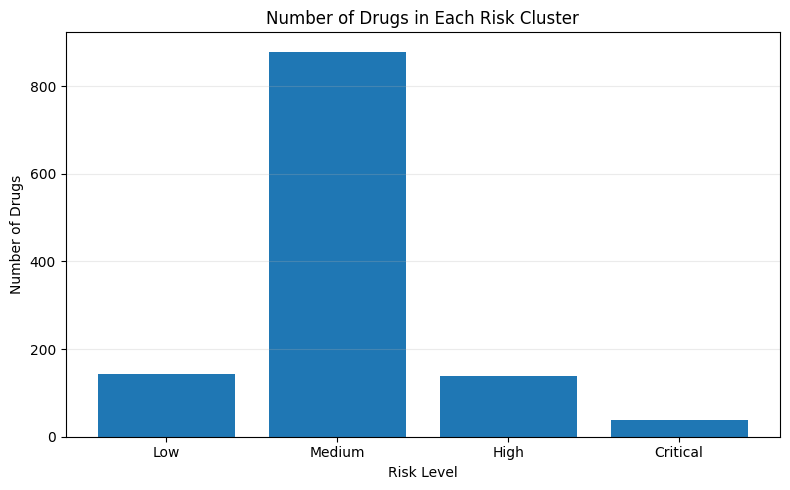

In [126]:
# Cell 12: Bar chart of drugs per cluster
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts["Risk_Level"],
    cluster_counts["Number_of_Drugs"],
)

plt.title("Number of Drugs in Each Risk Cluster")
plt.xlabel("Risk Level")
plt.ylabel("Number of Drugs")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

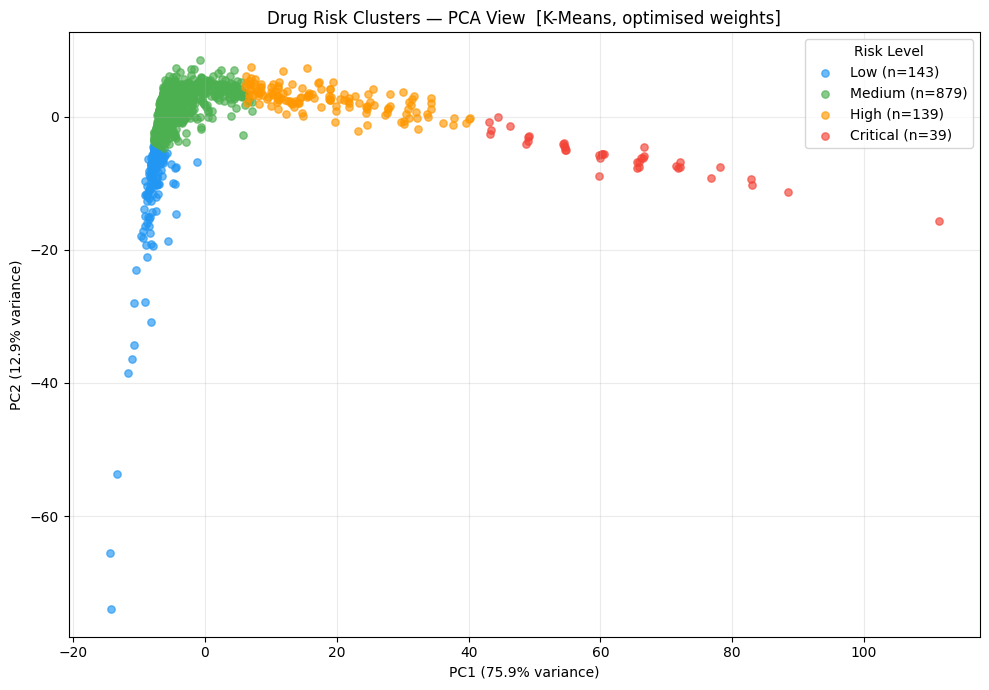

In [127]:
# Cell 16: PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_weighted)
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

variance_explained = pca.explained_variance_ratio_ * 100
colors = {"Low": "#2196F3", "Medium": "#4CAF50", "High": "#FF9800", "Critical": "#F44336"}

plt.figure(figsize=(10, 7))
for risk_level in risk_labels:
    subset = df[df["Risk_Level"] == risk_level]
    plt.scatter(subset["PCA1"], subset["PCA2"],
                label=f"{risk_level} (n={len(subset)})",
                color=colors[risk_level], alpha=0.65, s=28)

plt.title(f"Drug Risk Clusters — PCA View  [{final_algo}, optimised weights]")
plt.xlabel(f"PC1 ({variance_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({variance_explained[1]:.1f}% variance)")
plt.legend(title="Risk Level")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("pca_clusters_optimised.png", dpi=150)
plt.show()

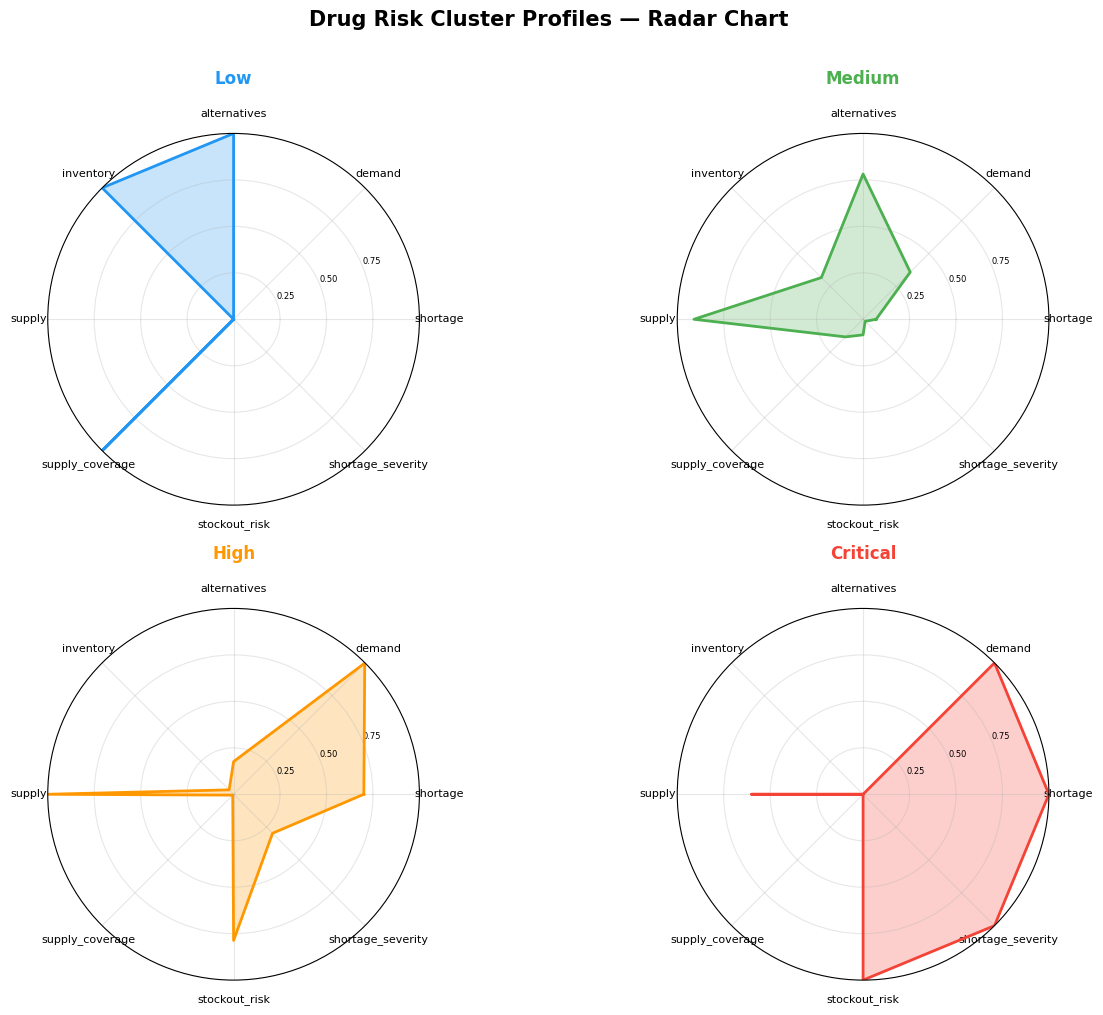

In [128]:
# Cell 17: Radar chart — cluster risk profiles across all 8 features
radar_features = all_features
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# Normalise each feature to [0, 1] across clusters for visual comparison
centers_norm = centers_original[radar_features].copy()
for col in radar_features:
    col_min, col_max = centers_norm[col].min(), centers_norm[col].max()
    if col_max > col_min:
        centers_norm[col] = (centers_norm[col] - col_min) / (col_max - col_min)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), subplot_kw=dict(polar=True))
fig.suptitle("Drug Risk Cluster Profiles — Radar Chart", fontsize=15, fontweight="bold", y=1.01)

for ax, risk_level in zip(axes.flat, risk_labels):
    values = centers_norm.loc[risk_level, radar_features].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[risk_level], linewidth=2)
    ax.fill(angles, values, color=colors[risk_level], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.50", "0.75"], size=6)
    ax.set_title(risk_level, color=colors[risk_level], fontweight="bold", pad=18, size=12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_radar_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [129]:
# Cell 14: Export clustering results
OUTPUT_PATH = Path("clustered_drug_results.csv")

df.to_csv(OUTPUT_PATH, index=False)

print(f"Results exported to: {OUTPUT_PATH}")

Results exported to: clustered_drug_results.csv
